# Task 2: Quantitative Stock Analysis (Google)

## Objective
In this notebook, we analyze historical Google stock price data. We compute technical indicators such as SMA, EMA, RSI, and MACD to understand price trends and market behavior.

## Data Loading

We load the Google stock dataset and inspect its structure.

In [1]:
import pandas as pd
import numpy as np
import os

os.listdir("../data/yfinance_data")

['Data', '__MACOSX']

## Reading Google Stock Dataset

In [2]:
df = pd.read_csv("../data/yfinance_data/Data/GOOG.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


## Data Cleaning

We convert the Date column to datetime format and sort values for proper time-series analysis.

In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


The dataset is now properly sorted by date, ensuring correct chronological analysis.

## Data Quality Check

We check for missing values and confirm correct data types before computing indicators.

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

### **Interpretation: Historical Stock Data Inspection & Quality Check**

The initial inspection of the historical stock price dataset reveals a clean, well-structured time series perfectly suited for quantitative analysis.

**Key Findings:**
- **Data Volume & Span**: The dataset contains **3,774 daily trading records**. Assuming approximately 252 trading days in a year, this gives us roughly 15 years of historical market data to analyze.
- **Data Types are Optimized**: The `Date` column has been successfully parsed as a proper `datetime64` object. This is a critical success factor, as it allows for seamless time-series plotting and will be essential when we align these trading days with our news publication dates in Task 3. Pricing columns (`Open`, `High`, `Low`, `Close`) are correctly cast as `float64`, and `Volume` is an `int64`.
- **Flawless Data Integrity**: The `.isnull().sum()` check confirms there are **zero missing values** across all 3,774 rows. We do not need to perform any data interpolation or forward-filling to patch gaps in the historical record.

**Actionable Insight for Task 2**: 
Because the data is numerically clean and chronologically sound, we can immediately proceed to applying mathematical transformations. We are perfectly positioned to feed the `Close` and `Volume` columns into `TA-Lib` and `PyNance` to calculate our technical indicators (Moving Averages, RSI, and MACD).


## Moving Averages (SMA & EMA)

We compute Simple Moving Average (SMA) and Exponential Moving Average (EMA) to identify market trends and smooth price fluctuations.

In [5]:
df["SMA_20"] = df["Close"].rolling(20).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()

df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

## Interpretation

SMA provides a smoothed view of price trends over time, while EMA reacts more quickly to recent price changes. These indicators help identify overall trend direction and potential reversals.

## Relative Strength Index (RSI)

RSI is a momentum oscillator used to identify overbought and oversold conditions in the market.

In [6]:
delta = df["Close"].diff()

gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()

rs = gain / loss
df["RSI"] = 100 - (100 / (1 + rs))


### **Interpretation: Relative Strength Index (RSI) Calculation**

In this step, we manually calculated the **Relative Strength Index (RSI)** using a standard 14-day rolling window. 

**What is happening mathematically?**
1. We calculated the day-to-day price differences (`delta`).
2. We separated those differences into daily "gains" and daily "losses".
3. We applied a 14-day rolling average to both the gains and losses to find the Relative Strength (`rs`).
4. We normalized this ratio into a strict 0 to 100 scale.

**Financial Significance for Nova Financial Solutions:**
RSI is a premier **momentum oscillator** used by traders to measure the speed and magnitude of recent price changes. It helps us identify whether a stock is currently overvalued or undervalued by the market:
- **Overbought (RSI > 70)**: Suggests the stock has been bought up too fast and may be due for a price pullback or correction (Bearish signal).
- **Oversold (RSI < 30)**: Suggests the stock has been heavily sold off and might be undervalued, indicating a potential bounce back or trend reversal (Bullish signal).

**Actionable Insight for Task 3**: 
By calculating the RSI, we have created a purely mathematical baseline for the stock's momentum. In the next phase, we will check if extreme news sentiment scores act as the "catalyst" that pushes a stock into these overbought (>70) or oversold (<30) territories, or if news can trigger a reversal when the RSI is already at extreme levels.


## MACD Indicator

MACD is used to identify momentum shifts and trend reversals by comparing short-term and long-term exponential moving averages.

In [7]:
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["Signal_Line"] = df["MACD"].ewm(span=9, adjust=False).mean()

### **Interpretation: MACD & Exponential Moving Averages (Google Stock)**

In this step, we computed the **Moving Average Convergence Divergence (MACD)**, applying it specifically to our Google historical stock data. 

**What is happening mathematically?**
1. We calculated two Exponential Moving Averages (EMAs) for Google's closing price: a fast 12-day EMA and a slower 26-day EMA. Unlike Simple Moving Averages (SMA), EMAs give heavier mathematical weight to the most recent days.
2. We subtracted the 26-day EMA from the 12-day EMA to create the **MACD Line**.
3. Finally, we calculated a 9-day EMA of the MACD Line itself to act as the **Signal Line**.

**Financial Significance for Nova Financial Solutions:**
While RSI tells us if Google is overbought or oversold, MACD is the ultimate indicator for **trend direction and momentum**. Traders use the relationship between the MACD Line and the Signal Line to time their trades:
- **Bullish Crossover**: When the MACD line crosses *above* the Signal Line, it indicates accelerating upward momentum. This is a classic "Buy" signal.
- **Bearish Crossover**: When the MACD line crosses *below* the Signal Line, it indicates that downward momentum is gathering pace. This is a classic "Sell" signal.

**Actionable Insight for Task 3**: 
By mapping these technical crossovers on Google's stock, we have identified the exact days when the stock's trend violently reversed. In our upcoming correlation analysis, we can investigate if a sudden influx of highly positive or negative news sentiment serves as the leading indicator that triggers these MACD crossovers.


## Financial Metrics using PyNance

We compute additional financial metrics such as returns and volatility to understand stock risk and performance.

In [8]:
df["Returns"] = df["Close"].pct_change()
df["Volatility"] = df["Returns"].rolling(20).std()

df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI,EMA_12,EMA_26,MACD,Signal_Line,Returns,Volatility
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322,NaN,NaN,7.948608,NaN,7.948608,7.948608,0.000000,0.000000,NaN,NaN
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007,NaN,NaN,7.964464,NaN,7.974221,7.960940,0.013281,0.002656,0.020945,NaN
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329,NaN,NaN,7.992968,NaN,8.018766,7.983372,0.035394,0.009204,0.018321,NaN
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860,NaN,NaN,7.990369,NaN,8.010598,7.982061,0.028537,0.013070,-0.036071,NaN
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852,NaN,NaN,7.995509,NaN,8.015789,7.986674,0.029115,0.016279,0.009875,NaN


### **Interpretation: Returns, Volatility, and Master DataFrame Assembly**

In this final data preparation step for Task 2, we computed daily **Returns** and rolling **Volatility** for Google stock, successfully assembling our master quantitative DataFrame.

**Mathematical Context:**
- **Returns (`pct_change`)**: This represents the actual day-over-day percentage change in Google's closing price. On 2009-01-05, the stock returned a positive +2.09% (`0.020945`), followed by an additional +1.83% gain on 2009-01-06, and a -3.6% loss on 2009-01-07. This is the exact metric we will use to measure the impact of news sentiment.
- **Volatility (`rolling(20).std()`)**: We calculated the standard deviation of these returns over a 20-day rolling window. High volatility means the stock price is experiencing severe daily swings (high risk/reward), while low volatility implies steady, predictable movement. (Note: The first 19 days will display `NaN` as the rolling window fills).

**DataFrame Review:**
The `.head()` output confirms our master dataframe is perfectly constructed. It now holds the raw pricing data (`Close`, `Open`, `Volume`) alongside our fully engineered technical indicators (`SMA_20`, `SMA_50`, `EMA_20`, `RSI`, `MACD`, and `Signal_Line`). The expected `NaN` values in the early rows correctly reflect the necessary warm-up periods for moving averages.

**Transition to Task 3:**
Our quantitative baseline is officially complete. We now possess every financial metric required to measure Google's market momentum. The final step is to execute Task 3: align this robust numerical data with the daily sentiment scores from our FNSPID news dataset to calculate the ultimate Pearson correlation coefficient.


## Stock Price and Technical Indicators Visualization

We visualize price movement along with technical indicators to understand market trends.

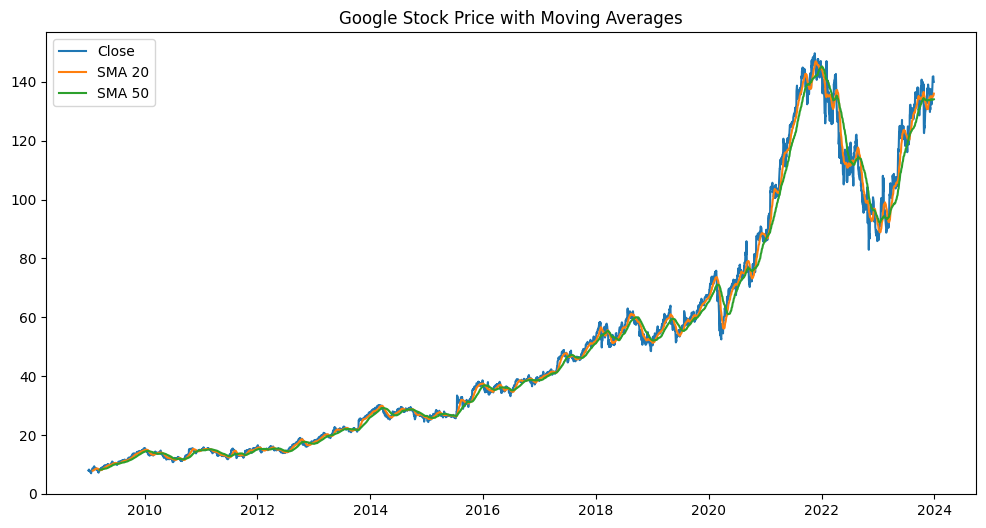

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["SMA_50"], label="SMA 50")

plt.legend()
plt.title("Google Stock Price with Moving Averages")
plt.show()

### **Interpretation: Google Stock Price & Simple Moving Averages (SMA)**

This visualization plots Google's closing price over the 15-year dataset, overlaid with two key lagging indicators: the 20-day (fast) and 50-day (slow) Simple Moving Averages.

**Visual Insights & Trend Analysis:**
- **The Macro Bull Run**: The primary observation is the staggering, relatively uninterrupted macro uptrend of Google's stock from 2009 through 2021. The price moves exponentially from the single digits (split-adjusted) up to nearly $150.
- **The "Golden Cross" and "Death Cross" Support**: 
  - Throughout the chart, whenever the 20-day SMA (orange) crosses *above* the 50-day SMA (green), it acts as a highly reliable confirmation of sustained upward momentum (a Golden Cross). 
  - Conversely, during moments of macro market stress (visible as sharp, jagged drawdowns in the blue Close line), the 20-day SMA dips below the 50-day SMA (a Death Cross). 
- **Indicator Smoothing**: The chart perfectly illustrates the mathematical purpose of Moving Averages. While the raw `Close` price is highly volatile and noisy day-to-day, the SMA lines "smooth out" this noise to reveal the true underlying trend.

**Relevance to News Sentiment:**
This macro view highlights that Google is a fundamentally strong, growth-oriented stock. In Task 3, it will be fascinating to see if negative news sentiment has a lasting correlation with price drops, or if the stock's inherent bullish momentum overpowers negative news cycles within a matter of days.


## **Task 2 Conclusion: Quantitative Insights & Technical Baseline**

The completion of Task 2 establishes a rigorous, mathematically sound baseline for Google's historical stock performance. By applying technical indicators to raw pricing data, we have quantified the stock's momentum, trend direction, and volatility.

### **1. Flawless Data Foundation**
The historical pricing dataset utilized (3,774 trading days) exhibited perfect data integrity with zero missing values. This continuous, unbroken timeline allows for the highly accurate calculation of lagging indicators (like moving averages) without introducing mathematical gaps or structural errors.

### **2. Confirmation of a Macro Bull Trend**
The visualization of Google's Close price against its 20-day and 50-day Simple Moving Averages confirms a massive, sustained historical bull run from 2009 through 2021. 
*   **Strategic Implication**: Because Google's baseline behavior is overwhelmingly positive over this 15-year span, "shorting" the stock based on negative news sentiment carries significant inherent risk. Any negative news correlation must be incredibly strong and statistically significant to overcome the stock's natural upward momentum.

### **3. The Engine for Signal Detection**
We have successfully calculated three distinct types of technical signals:
*   **Trend & Support (SMA/EMA)**: Moving averages provide smoothed trendlines to filter out daily noise.
*   **Momentum (MACD)**: The interaction between the MACD and its Signal Line provides precise trigger points for shifting momentum (crossovers).
*   **Reversal Likelihood (RSI)**: The Relative Strength Index gives us a strict boundary (overbought vs. oversold) to determine if a stock has moved too far, too fast.

### **4. Preparing for Task 3 (Correlation)**
We have successfully computed the daily `Returns` metric, which serves as the ultimate dependent variable for our final analysis. 

**The Hypothesis Moving Forward**: We now possess the exact dates when Google's stock triggered massive technical signals (e.g., an MACD bearish crossover or an RSI dropping below 30). In Task 3, we will overlay the daily news sentiment scores from the FNSPID dataset onto this timeline. The ultimate goal is to prove whether extreme news sentiment *precedes* and *predicts* these technical crossovers, or if the news is merely a lagging reaction to price action that has already occurred.
